In [1]:
from pathlib import Path

folder_path = Path("./generalizability")  # Replace with your folder path

# List all .pt files
pt_files = list(folder_path.glob("*.pt"))

# Print the list
print("Found .pt files:")
for file in pt_files:
    size_mb = file.stat().st_size / (1024 * 1024)  # Size in MB
    print(f"{file.name} ({size_mb:.2f} MB)")

Found .pt files:
dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_test_ntimepoints21_LogGRF_rq_length_scale0.100_variance0.700_alpha1.500_exp_factor2.500_vmax0_vmin-1_batch0_all_frames.pt (55.00 MB)
dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_test_ntimepoints21_GRF_matern_alpha3.500_tau7_vmax1_vmin0_batch0_all_frames.pt (55.00 MB)
dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_test_ntimepoints21_LogGRF_rq_length_scale0.100_variance0.700_alpha1.700_exp_factor2.500_vmax1_vmin0_batch0_all_frames.pt (55.00 MB)
dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_test_ntimepoints21_NegLogGRF_rbf_length_scale0.050_variance0.500_exp_factor2.500_vmax-1_vmin-1.5_batch0_all_frames.pt (55.00 MB)
dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_test_ntimepoints21_LogGRF_matern_alpha2_tau3_exp_factor2.500_vmax1_vmin0_batch0_all_frames.pt (55.00 MB)
dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_test_ntimepoints21_NegLogGRF_matern_alpha1.500_tau1_exp_factor2.500_vmax-1_vmin-1.5_batch0_all_frames.pt (55.00 MB)
dim2d_nx

In [2]:
len(pt_files)

1440

In [3]:
import torch

idx = 500
selected_file = pt_files[idx]
print(f"\nLoading file: {selected_file.name}")

# Load the .pt file
data = torch.load(selected_file, weights_only=False)


Loading file: dim2d_nx256_N10_solver=exponax_nu0.000_t20.0_test_ntimepoints21_GRF_matern_alpha3.500_tau1_vmax1_vmin0_batch0_all_frames.pt


In [15]:
data["x"].shape

torch.Size([20, 256, 256])

In [16]:
data["y"].shape

torch.Size([20, 256, 256, 21])

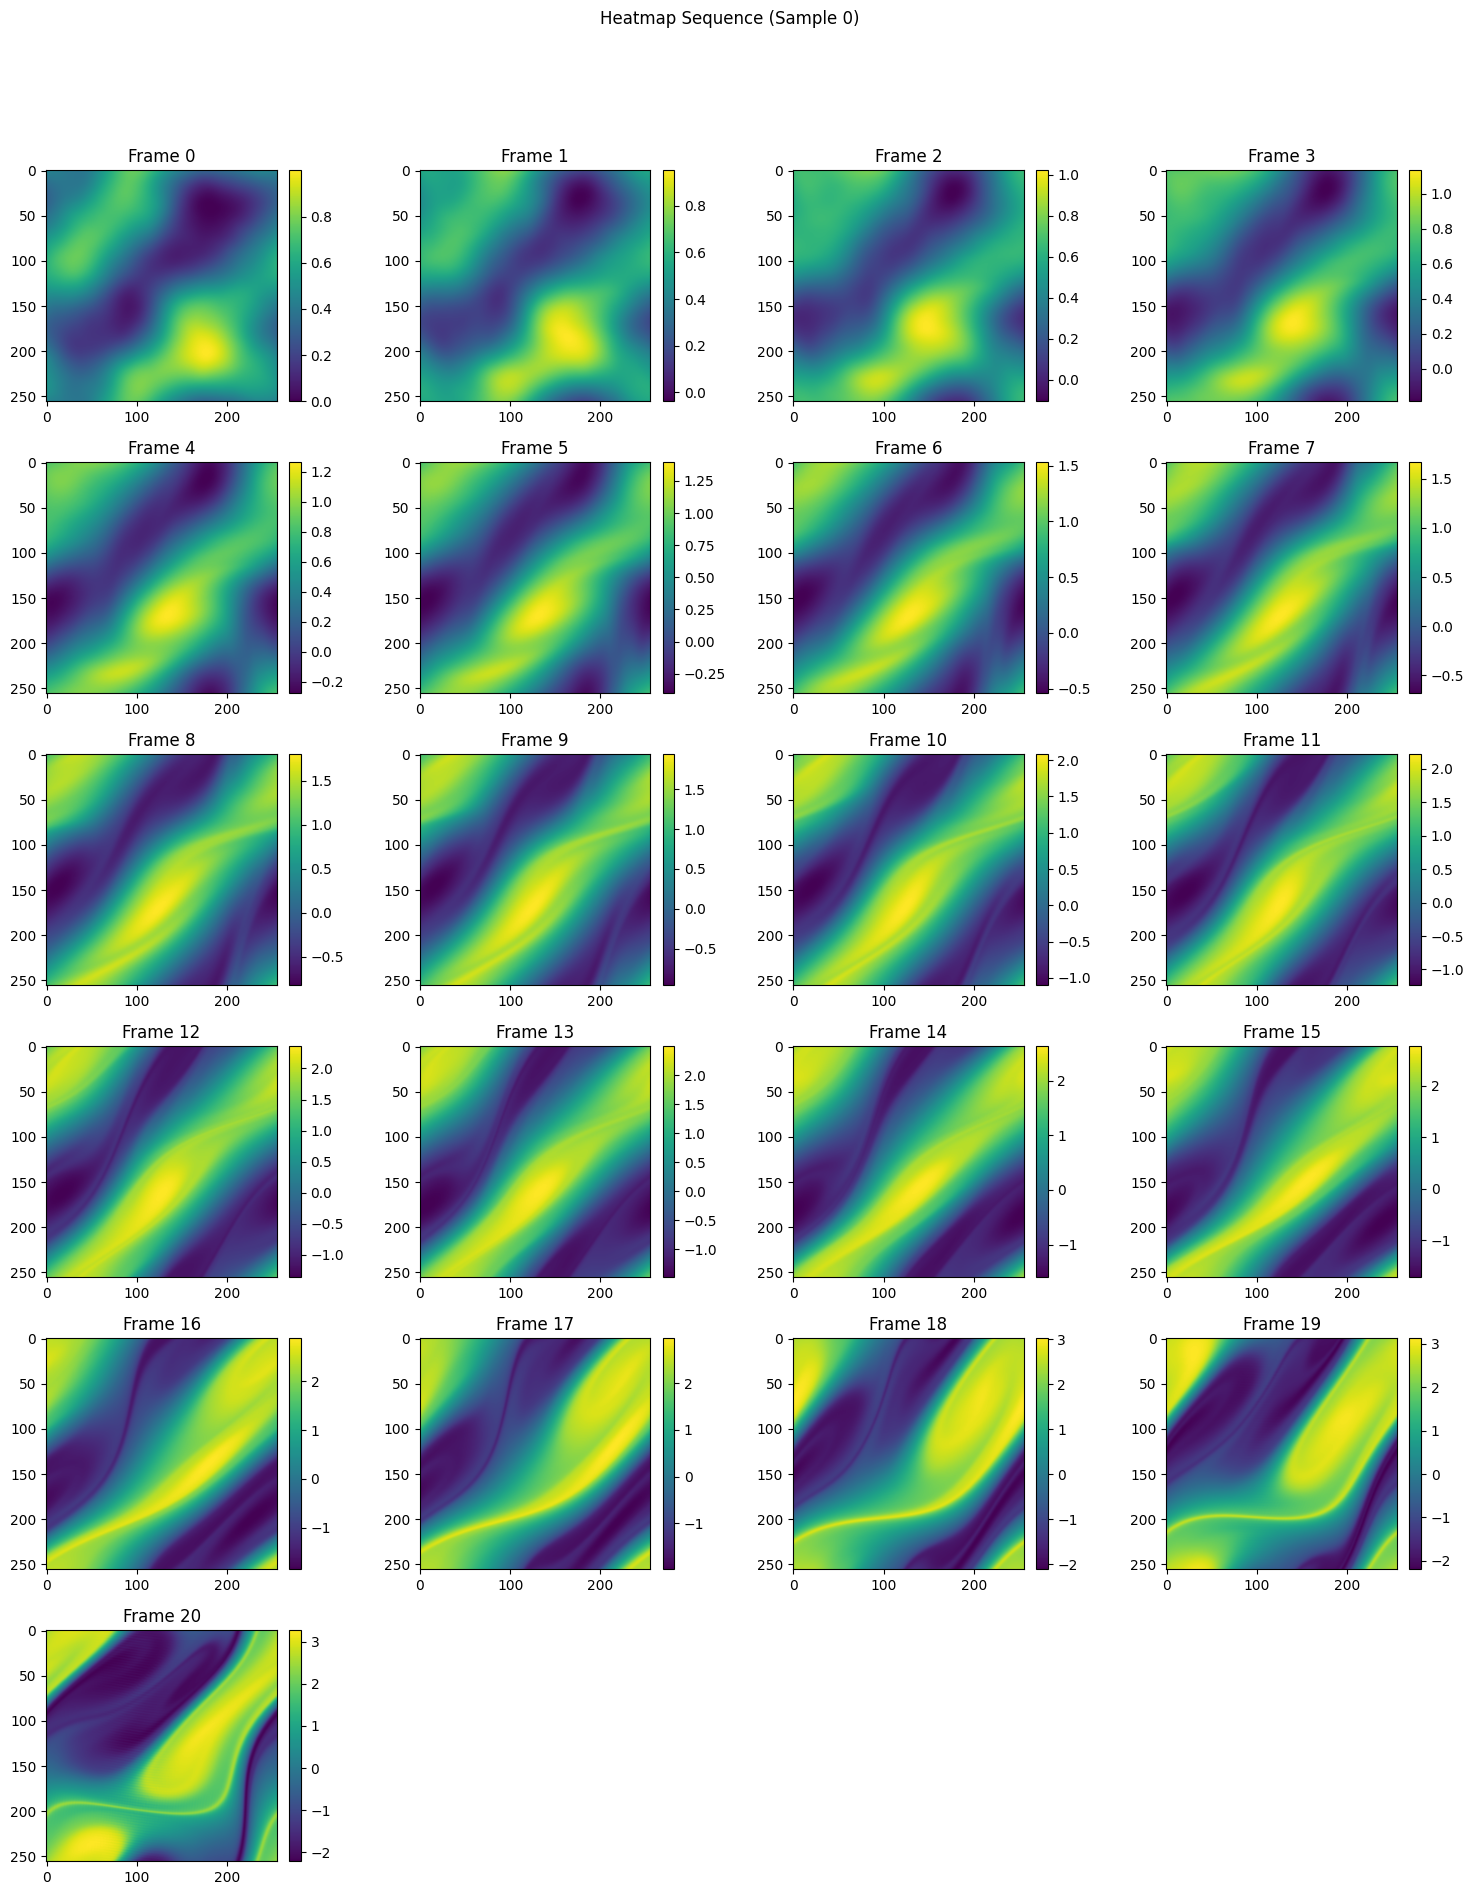

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming your data is loaded as: data = torch.load("your_file.pt")
index = 0  # The sample index you want to visualize
frame_indices = range(0, 21, 1)  # Frames 0, 2, 4, ..., 20

# Calculate how many rows/columns we need for subplots
n_frames = len(frame_indices)
n_cols = 4  # Number of columns in subplot grid
n_rows = int(np.ceil(n_frames / n_cols))

# Create the figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 3*n_rows))
fig.suptitle(f"Heatmap Sequence (Sample {index})", y=1.05)

# Flatten axes array for easy iteration if needed
if isinstance(axes, np.ndarray):
    axes = axes.flat
else:
    axes = [axes]

# Plot each frame
for i, frame_idx in enumerate(frame_indices):
    if i >= len(axes):  # Safety check
        break
        
    img = axes[i].imshow(data["y"][index,...,frame_idx], cmap='viridis')
    axes[i].set_title(f"Frame {frame_idx}")
    fig.colorbar(img, ax=axes[i], fraction=0.046, pad=0.04)

# Hide any empty subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()